# Paper figures
Run all cells to reproduce the three empirical figures from `data/` into `figures/`.
No simulations are launched. Requires LaTeX and `dvipng` for paper typography.
All three figures are displayed inline and saved locally in `figures/`.

The original schematic is a separate manuscript asset, not recreated here.
The `data/` folder contains only the ten archives used in these figures.

In [ ]:
from pathlib import Path
import shutil
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.integrate import cumulative_trapezoid
from IPython.display import display, Image

HERE = Path.cwd()
CODE = HERE if (HERE / "data").is_dir() else HERE / "code"
if not (CODE / "data").is_dir():
    raise RuntimeError("Run from the supplementary folder or its parent")
CODE = CODE.resolve()
DATA = CODE / "data"
OUT = CODE / "figures"
OUT.mkdir(exist_ok=True)

plt.rcParams.update(
    {
        "font.family": "serif",
        "font.size": 9,
        "axes.labelsize": 10,
        "legend.fontsize": 7,
        "pdf.fonttype": 42,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "figure.dpi": 130,
    }
)


def critical_s(c):
    # Includes the removable singularity at zero through critical_q.
    c = np.asarray(c)
    grid = np.linspace(0, max(float(np.max(c)), 1e-9), 20001)
    vals = cumulative_trapezoid(critical_q(grid), grid, initial=0)
    return np.interp(c, grid, vals)


## Data loading and normalization
All archives store total squared norms for inputs of norm sqrt(n).

In [ ]:
"""Load schema-v1 total squared norms and evaluate the critical profile."""
from pathlib import Path
import numpy as np


def critical_q(c):
    c = np.asarray(c, dtype=float)
    z = c * c / 2
    return np.divide(np.sinh(z), z, out=np.ones_like(z), where=z != 0)


def load_result(path):
    path = Path(path)
    with np.load(path, allow_pickle=False) as archive:
        d = {k: archive[k] for k in archive.files}
    result = d
    result["source"] = str(path.resolve())
    for key in ["width", "depth"]:
        result[key] = np.asarray(result[key], dtype=int)
    for key in ["mean", "std", "se", "c_eff"]:
        result[key] = np.asarray(result[key], dtype=float)
    return result


def per_width(result):
    for n in np.unique(result["width"]):
        ids = np.flatnonzero(result["width"] == n)
        ids = ids[np.argsort(result["depth"][ids], kind="stable")]
        yield int(n), {
            k: result[k][ids] for k in ["depth", "c_eff", "mean", "std", "se"]
        }


## Load the paper datasets


In [ ]:
complex_q = load_result(DATA / "activation_linear_complex_tied_isotropic.npz")
real_q = load_result(DATA / "activation_linear_real_tied_isotropic.npz")
activation_linear = load_result(DATA / "activation_linear.npz")
relu = load_result(DATA / "activation_relu.npz")
leaky05 = load_result(DATA / "activation_leaky_relu_alpha_0p5.npz")
untied_sets = [
    load_result(DATA / f"activation_{activation}_untied_isotropic.npz")
    for activation in ["linear", "relu", "leaky_relu"]
]
s_complex = load_result(DATA / "lru_linear_complex_tied_isotropic.npz")
s_real = load_result(DATA / "lru_linear_real_tied_isotropic.npz")


## Plotting helpers
Marker shape identifies activation; darker shades identify larger widths. Error bars are one estimated standard error.

In [ ]:
from matplotlib.colors import Normalize, LinearSegmentedColormap

# Shared sizing for all linear and nonlinear experiment panels.
PANEL_SIZE = (4.25, 2.5)
MARKER_AREA = 28
MARKER_EDGE_WIDTH = 0.35


def linear_panel(d, name, kind, cmap_name, ax):
    widths = np.unique(d["width"])
    norm = Normalize(min(widths), max(widths))
    cmap = LinearSegmentedColormap.from_list(
        cmap_name + "_widths", plt.get_cmap(cmap_name)(np.linspace(0.15, 0.95, 256))
    )
    factors = d["width"] if kind == "q" else d["width"] ** 1.5
    for n, r in per_width(d):
        factor = n if kind == "q" else n**1.5
        y = r["mean"] / factor
        se = r["se"] / factor
        ax.errorbar(
            r["c_eff"],
            y,
            yerr=np.vstack([np.minimum(se, 0.999 * y), se]),
            fmt="none",
            ecolor=cmap(norm(n)),
            alpha=0.35,
            elinewidth=0.65,
            capsize=1.5,
        )
    ax.scatter(
        d["c_eff"],
        d["mean"] / factors,
        c=d["width"],
        cmap=cmap,
        norm=norm,
        s=MARKER_AREA,
        edgecolors="black",
        linewidths=MARKER_EDGE_WIDTH,
        zorder=3,
    )
    grid = np.linspace(0.001, max(d["c_eff"]), 800)
    ax.plot(
        grid,
        critical_q(grid) if kind == "q" else critical_s(grid),
        color="black",
        alpha=0.6,
        lw=1.3,
    )
    ax.set(
        yscale="log",
        xlabel=r"$c=k/\sqrt{n}$" if kind == "q" else r"$c=t/\sqrt{n}$",
        ylabel=r"$Q_{n,k}$"
        if kind == "q"
        else r"$n^{-1/2}S_{n,t}$",
    )
    handles = [
        Line2D(
            [0],
            [0],
            marker="o",
            ls="none",
            color=cmap(norm(n)),
            markeredgecolor="black",
            markersize=4,
            label=f"$n={n}$",
        )
        for n in widths
    ]
    ax.legend(
        handles=handles,
        loc="center left",
        bbox_to_anchor=(1, 0.5),
        frameon=False,
        fontsize=7,
    )
    ax.grid(alpha=0.2)
    return ax


In [ ]:
# Shape identifies activation (and LeakyReLU slope); darkness identifies width.
ACTIVATION_PALETTES = {"linear": "Greys", "relu": "Reds", "leaky_relu": "Greens"}
activation_sets = [
    ("Linear", activation_linear, ACTIVATION_PALETTES["linear"], "o"),
    ("ReLU", relu, ACTIVATION_PALETTES["relu"], "s"),
    (r"LeakyReLU $\alpha=0.5$", leaky05, ACTIVATION_PALETTES["leaky_relu"], "v"),
]
width_norm = Normalize(100, 1000)


def width_colour(cmap_name, n):
    return plt.get_cmap(cmap_name)(0.15 + 0.8 * width_norm(n))


def activation_points(ax, d, cmap_name, marker, per_coordinate=True, omit_initial=False, hollow=False, x_offset=0.0, omit_points=()):
    for n, r in per_width(d):
        colour = width_colour(cmap_name, n)
        # All activation archives store total energy for radius-sqrt(n) inputs.
        factor = n if per_coordinate else n * float(d["initial_norm"]) ** 2
        y = r["mean"] / factor
        valid = np.isfinite(r["se"]) & (r["se"] >= 0)
        for omitted_n, omitted_t in omit_points:
            if n == omitted_n:
                valid &= r["depth"] != omitted_t
        if omit_initial:
            valid &= r["depth"] > 0
        # Only log-axis lower whiskers need clipping; the means are unmodified.
        se = r["se"][valid] / factor
        lower = np.minimum(se, 0.999 * y[valid]) if ax.get_yscale() == "log" else se
        ax.errorbar(
            r["c_eff"][valid] + x_offset,
            y[valid],
            yerr=np.vstack([lower, se]),
            fmt="none",
            ecolor=colour,
            alpha=0.35,
            elinewidth=0.6,
            capsize=1.5,
        )
        ax.scatter(
            r["c_eff"][valid] + x_offset,
            y[valid],
            marker=marker,
            s=MARKER_AREA,
            facecolors="none" if hollow else colour,
            edgecolors=colour if hollow else "black",
            linewidths=0.8 if hollow else MARKER_EDGE_WIDTH,
            zorder=5 if str(d["activation"]) == "relu" else 3,
        )


def activation_legend(entries):
    return [
        Line2D(
            [0],
            [0],
            marker=marker,
            ls="none",
            markerfacecolor=plt.get_cmap(cmap)(0.65),
            markeredgecolor="black",
            markersize=5,
            label=label,
        )
        for label, d, cmap, marker in entries
    ]



## Complex and real linear figures

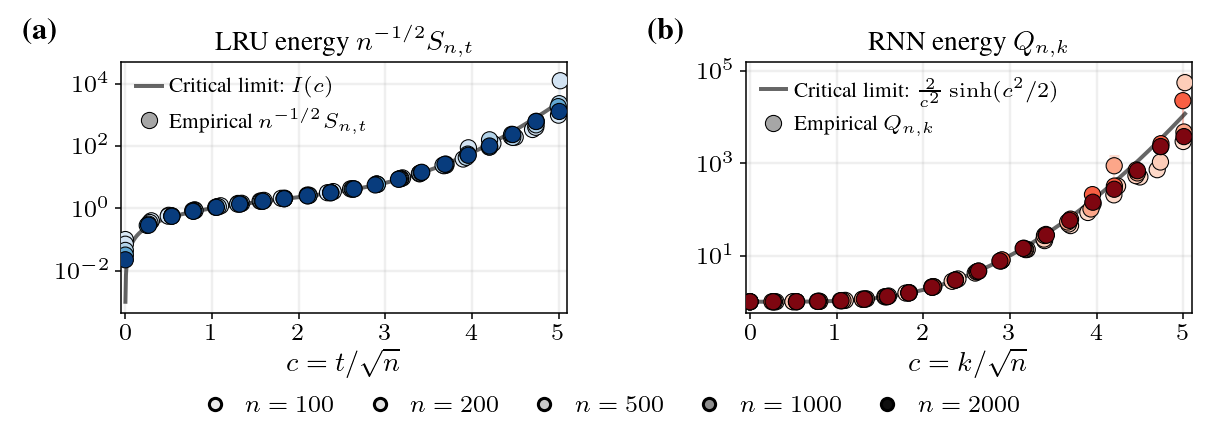

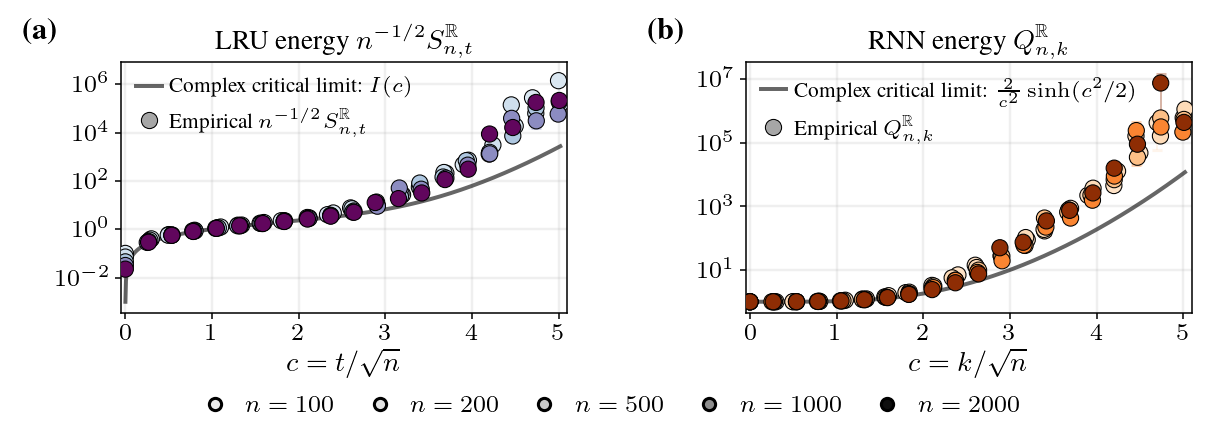

In [ ]:

# Full figures: physical sizes and typography are specified at manuscript scale.
# Requires a TeX installation with latex and dvipng.
for executable in ["latex", "dvipng"]:
    if shutil.which(executable) is None:
        raise RuntimeError(f"Install TeX Live/MacTeX and add {executable} to PATH")

PAPER_STYLE = {
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{times}\usepackage{amsmath,amssymb}",
    "font.family": "serif", "font.serif": ["Computer Modern Roman"],
    "font.size": 9, "axes.labelsize": 9, "axes.titlesize": 9,
    "xtick.labelsize": 8, "ytick.labelsize": 8, "legend.fontsize": 7,
    "axes.spines.top": True, "axes.spines.right": True,
    "axes.linewidth": 0.5, "xtick.major.width": 0.5, "ytick.major.width": 0.5,
}


def paper_canvas():
    fig, axes = plt.subplots(1, 2, figsize=(5.5, 1.95))
    fig.subplots_adjust(left=0.10, right=0.985, bottom=0.27, top=0.855, wspace=0.40)
    for letter, ax in zip("ab", axes):
        ax.text(-0.22, 1.09, r"\textbf{(" + letter + ")}",
                transform=ax.transAxes, fontsize=10)
        ax.tick_params(pad=1.5, length=2)
        ax.xaxis.labelpad = 1.5
    return fig, axes


def paper_finish(fig, name):
    # Fixed canvas, without tight cropping: preserves font/marker sizes on inclusion.
    fig.savefig(OUT / (name + ".pdf"))
    fig.savefig(OUT / (name + ".png"), dpi=220)
    plt.close(fig)
    display(Image(filename=str(OUT / (name + ".png")), width=792))


def shared_width_legend(fig, widths):
    widths = np.unique(widths)
    shade_norm = Normalize(min(widths), max(widths))
    handles = [Line2D([0], [0], marker="o", ls="none",
                      markerfacecolor=plt.get_cmap("Greys")(0.15 + 0.8 * shade_norm(n)),
                      markeredgecolor="black", markersize=4,
                      label=f"$n={n}$") for n in widths]
    fig.legend(handles=handles,
               loc="lower center", bbox_to_anchor=(0.5, -0.005), ncol=len(widths),
               frameon=False, fontsize=8, handletextpad=0.25, columnspacing=0.85,
               borderaxespad=0.15)


with plt.rc_context(PAPER_STYLE):
    for name, sd, qd, maps, real in [
        ("paper_linear_complex", s_complex, complex_q, ("Blues", "Reds"), False),
        ("paper_linear_real", s_real, real_q, ("BuPu", "Oranges"), True),
    ]:
        fig, axes = paper_canvas()
        for ax, d, kind, cmap in zip(axes, [sd, qd], ["s", "q"], maps):
            linear_panel(d, "", kind, cmap, ax=ax)
            ax.get_legend().remove()
            ax.set_xlim(-0.05, 5.1)
            superscript = r"^{\mathbb{R}}" if real else ""
            if kind == "s":
                quantity = r"n^{-1/2}S" + superscript + r"_{n,t}"
                title = "LRU energy"
                formula = r"$I(c)$"
            else:
                quantity = "Q" + superscript + r"_{n,k}"
                title = "RNN energy"
                formula = r"$\frac{2}{c^2}\sinh(c^2/2)$"
            ax.set_ylabel("")
            ax.set_title(title + " $" + quantity + "$", pad=4)
            theory_label = ("Complex critical limit: " if real else "Critical limit: ") + formula
            theory_handle = Line2D([0], [0], color="black", alpha=0.6, lw=1.3,
                                   label=theory_label)
            empirical_handle = Line2D([0], [0], marker="o", ls="none",
                                      markerfacecolor="0.65", markeredgecolor="black",
                                      markeredgewidth=MARKER_EDGE_WIDTH,
                                      markersize=np.sqrt(MARKER_AREA),
                                      label="Empirical $" + quantity + "$")
            ax.legend(handles=[theory_handle, empirical_handle], loc="upper left",
                      frameon=False, fontsize=7, handlelength=1.2,
                      handletextpad=0.35, labelspacing=0.4, borderpad=0.2)
        shared_width_legend(fig, sd["width"])
        paper_finish(fig, name)



## Tied and untied activations
All activation archives use covariance-I spherical inputs. Means and SEs in
both panels are divided by width. The tied archives were rescaled exactly
from unit-input runs using positive homogeneity.
Panel b uses horizontal offsets solely for visibility. The ReLU observation
at n=100, t=50 (Q=0.972761, SE=0.008911) is omitted from the display,
as noted in the paper caption, and remains in the saved data.
Points with unavailable SEs are also omitted.

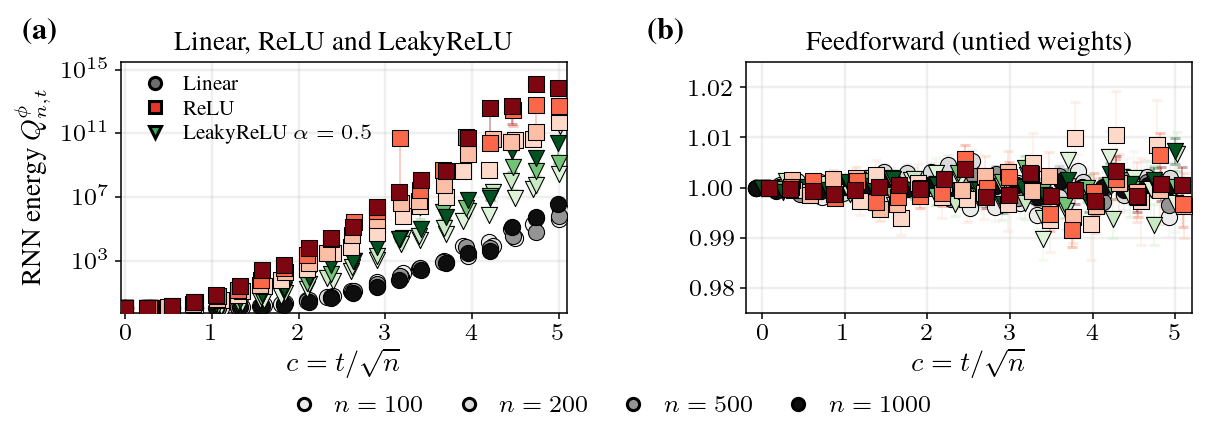

In [ ]:

# Tied recurrences and untied feedforward networks.
with plt.rc_context(PAPER_STYLE):
    fig, axes = paper_canvas()
    for ax in axes[:1]:
        ax.set_yscale("log")
        for _, d, cmap, marker in sorted(activation_sets,
                key=lambda entry: str(entry[1]["activation"]) == "relu"):
            activation_points(ax, d, cmap, marker)
        ax.set(xlabel=r"$c=t/\sqrt{n}$", ylabel=r"RNN energy $Q^\phi_{n,t}$",
               xlim=(-0.05, 5.1), ylim=axes[0].get_ylim())
        ax.set_ylim(bottom=0.5)
        ax.grid(alpha=0.2)
    axes[0].set_title("Linear, ReLU and LeakyReLU", pad=4)
    axes[0].legend(handles=activation_legend(activation_sets), loc="upper left",
                   frameon=False, fontsize=7, labelspacing=0.25,
                   handletextpad=0.3, borderpad=0.1, markerscale=0.8)
    ax = axes[1]
    ax.clear()
    ax.text(-0.22, 1.09, r"\textbf{(b)}", transform=ax.transAxes, fontsize=10)
    ax.tick_params(pad=1.5, length=2)
    ax.xaxis.labelpad = 1.5
    ax.set_title("Feedforward (untied weights)", pad=4)
    ax.set(xlabel=r"$c=t/\sqrt{n}$", ylabel="",
           xlim=(-0.2, 5.2))
    for d in sorted(untied_sets, key=lambda d: str(d["activation"]) == "relu"):
        activation = str(d["activation"])
        marker = {"linear": "o", "relu": "s", "leaky_relu": "v"}[activation]
        activation_points(ax, d, ACTIVATION_PALETTES[activation], marker,
                          hollow=False,
                          omit_points=((100, 50),) if activation == "relu" else (),
                          x_offset={"linear": -0.08, "leaky_relu": 0., "relu": 0.08}[activation])
    # Limits retain all displayed means and one-SE bars.
    ax.set_ylim(0.975, 1.025)
    ax.set_yticks([0.98, 0.99, 1.00, 1.01, 1.02])
    ax.grid(alpha=0.2)
    shared_width_legend(fig, activation_linear["width"])
    paper_finish(fig, "paper_nonlinear")
